In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/final/final_dataset.csv")

df.head()

,State,Commodity_Group,Commodity,Date,Arrival,Arrival_Unit,Modal_Price,Price_Unit,District,Max_Temp,...,Day,Weekend,DayOfWeek,Quarter,Lag_1,Lag_2,Lag_3,Rolling_7,Rolling_30,Price_Change
0,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Ahmednagar,28.9,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
1,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Pune,29.9,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
2,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Nashik,28.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
3,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Solapur,31.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
4,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Nagpur,27.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0


In [3]:
df["Date"] = pd.to_datetime(df["Date"])

In [4]:
df = df.drop(columns=[
    "Arrival_Unit",
    "Price_Unit",
    "Rain_mm"
])

df.head()

,State,Commodity_Group,Commodity,Date,Arrival,Modal_Price,District,Max_Temp,Min_Temp,Rainfall_mm,...,Day,Weekend,DayOfWeek,Quarter,Lag_1,Lag_2,Lag_3,Rolling_7,Rolling_30,Price_Change
0,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,1369.7,Ahmednagar,28.9,14.3,0.0,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
1,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,1369.7,Pune,29.9,14.2,0.0,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
2,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,1369.7,Nashik,28.4,11.9,0.0,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
3,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,1369.7,Solapur,31.4,19.7,0.0,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
4,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,1369.7,Nagpur,27.4,16.2,0.0,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0


In [5]:
label_encoders = {}

categorical_columns = [
    "State",
    "Commodity_Group",
    "Commodity",
    "District",
    "Festival"
]

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

In [6]:
df["Weekend"] = df["Weekend"].astype(int)

In [7]:
df = df.drop(columns=["Date"])

In [8]:
X = df.drop(columns=["Modal_Price"])

y = df["Modal_Price"]

print(X.shape)

print(y.shape)

(54340, 23)
(54340,)


# Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(43472, 23)
(10868, 23)


# Traine Random Forest

In [12]:
model = RandomForestRegressor(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)

model.fit(

    X_train,

    y_train

)

print("Training Completed")

Training Completed


# Prediction

In [11]:
y_pred = model.predict(X_test)

# Evalutaion

In [13]:
mae = mean_absolute_error(

    y_test,

    y_pred

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        y_pred

    )

)

r2 = r2_score(

    y_test,

    y_pred

)

print("MAE :", round(mae,2))

print("RMSE:", round(rmse,2))

print("R2 :", round(r2,4))

MAE : 4.32
RMSE: 95.62
R2 : 0.995


# important featurece

In [14]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance

,Feature,Importance
17,Lag_1,0.984292
22,Price_Change,0.009821
20,Rolling_7,0.005114
3,Arrival,0.000143
21,Rolling_30,0.000079
15,DayOfWeek,0.000057
12,Year,0.000057
11,Month,0.000055
5,Max_Temp,0.000051
6,Min_Temp,0.000045


# Plot

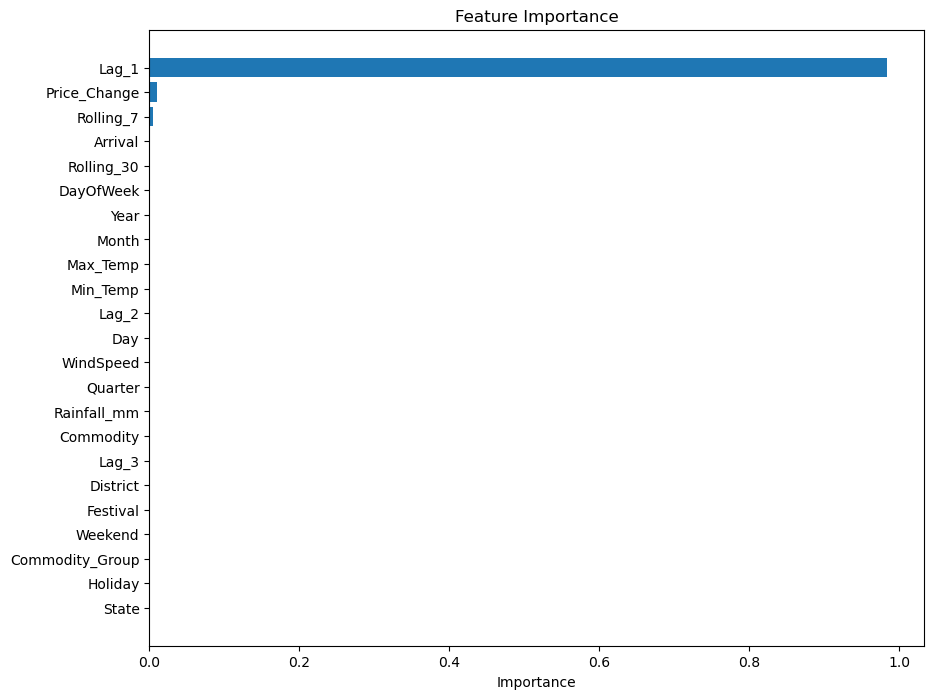

In [15]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [16]:
joblib.dump(

    model,

    "../models/price_prediction_model.pkl"

)

print("Model Saved")

Model Saved


In [17]:
joblib.dump(

    label_encoders,

    "../models/label_encoders.pkl"

)

print("Encoders Saved")

Encoders Saved


In [18]:
loaded_model = joblib.load(

    "../models/price_prediction_model.pkl"

)

loaded_model

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)